# 📊 05 — Final Summary Report
## Privacy-Preserving Synthetic Student Attendance Analysis and Prediction System

**Department:** Computer Engineering & MCA (Extended Dataset)
**Year/Semester:** Third Year — Fifth Semester | Final Year — Third Semester
**Report Date:** August 2026
**Dataset:** Fully Synthetic — No real student data used at any stage.

---

## ⚠️ Synthetic Dataset Notice

> **All student records used in this project are 100% synthetic and computer-generated.**
> No real student names, roll numbers, email IDs, or any personally identifiable information (PII)
> are used at any point in this project. The dataset does not represent, map to, or expose any real
> classroom data. This project is built entirely on statistically modeled synthetic attendance records.

---

## 📌 Terminology Mapping Notice

This project uses the following consistent terminology across all notebooks, scripts, and outputs:

| Term Used in This Project | Equivalent Term (If Seen Elsewhere) | Definition |
|--------------------------|-------------------------------------|------------|
| **Regular** | Safe | `Attendance_Percentage >= 75%` |
| **Defaulter** | At Risk | `Attendance_Percentage < 75%` |

> **Note:** Early project drafts (PROJECT_PLAN.md) used the terms "Safe" and "At Risk".
> All data files, validation reports, and model scripts use **Regular** and **Defaulter** exclusively.
> This notebook uses **Regular** and **Defaulter** consistently throughout.

---

## 1. Project Objective

| # | Objective |
|---|-----------|
| 1 | Generate a synthetic, anonymous student attendance dataset that preserves realistic statistical properties without touching any real student identity. |
| 2 | Perform thorough **Exploratory Data Analysis (EDA)** to uncover attendance trends, distributions, and feature correlations. |
| 3 | Build a **Regression model** to predict a student's attendance percentage (`Attendance_Percentage`). |
| 4 | Build a **Classification model** to predict whether a student is **Defaulter** (attendance < 75%) or **Regular** (attendance >= 75%). |
| 5 | Visualize findings with professional charts and graphs. |
| 6 | Demonstrate responsible, ethical, privacy-preserving data science practices. |

---

## 2. Setup — Imports and Paths

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import joblib
import warnings
warnings.filterwarnings("ignore")

# ── Project Paths ────────────────────────────────────────────────────────────
BASE_DIR = r"d:\Data_Science_attendence_project"
DATA_FILE       = os.path.join(BASE_DIR, "data",    "student_attendance_205_students.csv")
MODELS_DIR      = os.path.join(BASE_DIR, "models")
OUTPUTS_DIR     = os.path.join(BASE_DIR, "outputs")
CHARTS_DIR      = os.path.join(OUTPUTS_DIR, "charts")

REG_RESULTS     = os.path.join(OUTPUTS_DIR, "regression_model_results.csv")
CLF_RESULTS     = os.path.join(OUTPUTS_DIR, "classification_model_results.csv")
BEST_REG_MODEL  = os.path.join(MODELS_DIR,  "best_regression_model.joblib")
BEST_CLF_MODEL  = os.path.join(MODELS_DIR,  "best_classification_model.joblib")

print("All paths configured.")
print(f"Dataset exists : {os.path.isfile(DATA_FILE)}")
print(f"Regression results exists : {os.path.isfile(REG_RESULTS)}")
print(f"Classification results exists: {os.path.isfile(CLF_RESULTS)}")
print(f"Best regression model exists : {os.path.isfile(BEST_REG_MODEL)}")
print(f"Best classification model exists : {os.path.isfile(BEST_CLF_MODEL)}")

All paths configured.
Dataset exists : True
Regression results exists : True
Classification results exists: True
Best regression model exists : True
Best classification model exists : True


## 3. Dataset Summary

**Source File:** `data/student_attendance_205_students.csv`
**Generation Script:** `src/extend_dataset_to_205.py`
**Validation Report:** `outputs/final_dataset_validation_report.txt` — 25 checks, all PASS

In [2]:
# Load dataset
df = pd.read_csv(DATA_FILE)

print("=" * 60)
print("  DATASET SUMMARY")
print("=" * 60)
print(f"  Total Rows         : {len(df):,}")
print(f"  Total Columns      : {len(df.columns)}")
print(f"  Unique Students    : {df['Student_ID'].nunique()}")
print(f"  Unique Subjects    : {df['Subject'].nunique()}")
print(f"  Missing Values     : {df.isnull().sum().sum()}")
print(f"  Duplicate Rows     : {df.duplicated().sum()}")
print(f"  Student ID Range   : {df['Student_ID'].min()} – {df['Student_ID'].max()}")
print(f"  Departments        : {sorted(df['Department'].unique())}")
print(f"  Subjects           : {sorted(df['Subject'].unique())}")
print()

print("  Attendance_Percentage Statistics:")
att = df["Attendance_Percentage"]
print(f"    Mean   : {att.mean():.2f}%")
print(f"    Median : {att.median():.2f}%")
print(f"    Std    : {att.std():.2f}%")
print(f"    Min    : {att.min():.2f}%")
print(f"    Max    : {att.max():.2f}%")
print()

status_counts = df["Attendance_Status"].value_counts()
total = len(df)
print("  Attendance Status Distribution:")
for label, count in status_counts.items():
    print(f"    {label:12} : {count:,} ({count/total*100:.2f}%)")
print("=" * 60)

  DATASET SUMMARY
  Total Rows         : 4,100
  Total Columns      : 21
  Unique Students    : 205
  Unique Subjects    : 5
  Missing Values     : 0
  Duplicate Rows     : 0
  Student ID Range   : STU0001 – STU0205
  Departments        : ['Computer Engineering', 'MCA']
  Subjects           : ['Computer Networks', 'Data Structures & Algorithms', 'Database Management Systems', 'Software Engineering', 'Theory of Computation']

  Attendance_Percentage Statistics:
    Mean   : 68.67%
    Median : 70.00%
    Std    : 20.21%
    Min    : 0.00%
    Max    : 100.00%

  Attendance Status Distribution:
    Defaulter    : 2,266 (55.27%)
    Regular      : 1,834 (44.73%)


### Dataset Columns (21 features)

| Column | Type | Description |
|--------|------|-------------|
| `Student_ID` | Categorical | Anonymous student identifier (STU0001 – STU0205) |
| `Gender` | Categorical | Male / Female |
| `Age` | Numeric | Student age |
| `Department` | Categorical | Computer Engineering / MCA |
| `Year` | Categorical | Third Year / Final Year |
| `Semester` | Categorical | Fifth Semester / Third Semester |
| `Subject` | Categorical | One of 5 subjects |
| `Attendance_Period` | Categorical | Period_1 – Period_4 |
| `Total_Classes` | Numeric | Total classes scheduled in that period |
| `Classes_Attended` | Numeric | Classes actually attended |
| `Previous_Attendance_Percentage` | Numeric | Prior semester attendance % |
| `Assignment_Score` | Numeric | Score on assignments |
| `Internal_Marks` | Numeric | Internal exam marks |
| `Study_Hours_Per_Week` | Numeric | Self-reported weekly study hours |
| `Medical_Leave_Days` | Numeric | Days of medical leave taken |
| `Travel_Distance_KM` | Numeric | Distance from home to college |
| `Previous_Exam_Score` | Numeric | Score in previous semester exam |
| `Late_Count` | Numeric | Number of late arrivals |
| `Online_Class_Attendance` | Numeric | Online session attendance % |
| `Attendance_Percentage` | Numeric | **Target (Regression):** % of classes attended |
| `Attendance_Status` | Categorical | **Target (Classification):** Regular / Defaulter |

---

## 4. Data Validation Summary

**Validation Script:** `src/validate_final_dataset.py`
**Report File:** `outputs/final_dataset_validation_report.txt`
**Date Run:** 2026-08-22

| Check | Description | Result |
|-------|-------------|--------|
| 1 | File exists at expected path | ✅ PASS |
| 2 | Total rows and columns correct (4,100 rows × 21 columns) | ✅ PASS |
| 3–4 | Unique students = 205 | ✅ PASS |
| 5 | Student_ID range: STU0001 – STU0205 | ✅ PASS |
| 6 | No null or malformed Student_IDs | ✅ PASS |
| 7–8 | Every student has exactly 20 rows (5 subjects × 4 periods) | ✅ PASS |
| 9 | Exactly 5 unique subjects found | ✅ PASS |
| 10 | Every student has all 5 subjects | ✅ PASS |
| 11 | No missing values (0 null cells) | ✅ PASS |
| 12 | No duplicate rows | ✅ PASS |
| 13 | Classes_Attended ≤ Total_Classes for all rows | ✅ PASS |
| 14 | Attendance_Percentage matches recalculated values (max diff = 0.0000) | ✅ PASS |
| 15–16 | Attendance_Status follows ≥75 / <75 rule; both labels present | ✅ PASS |
| 17 | Numeric ranges valid (Attendance_Percentage: 0–100) | ✅ PASS |
| 18 | No private data (names, roll numbers, emails) detected | ✅ PASS |

**Total Checks:** 25 | **Passed:** 25 | **Failed:** 0

> ✅ **ALL 25 CHECKS PASSED — Dataset is ready for machine learning.**

---

## 5. EDA Findings

All EDA analysis was conducted in `notebooks/01_exploratory_data_analysis.ipynb`
using `src/exploratory_analysis.py`. Charts are saved in `outputs/charts/`.

### 5.1 Attendance Distribution

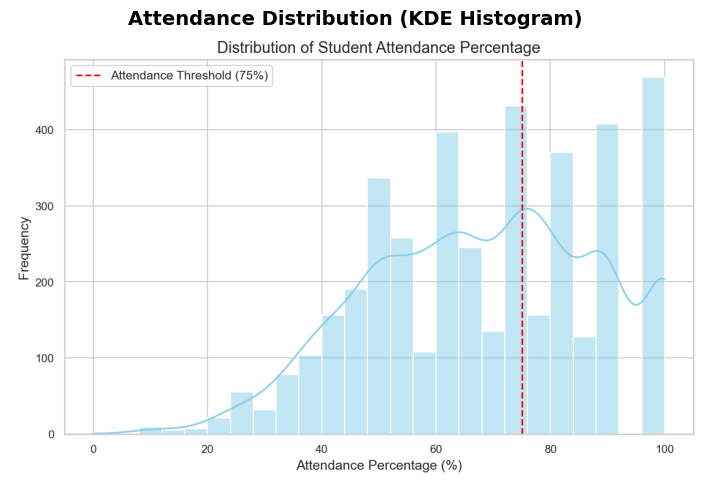

In [3]:
img_path = os.path.join(CHARTS_DIR, "attendance_distribution.png")
if os.path.isfile(img_path):
    img = mpimg.imread(img_path)
    plt.figure(figsize=(10, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Attendance Distribution (KDE Histogram)", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("[RESULT NOT AVAILABLE - RUN THE RELEVANT NOTEBOOK]")

**Key Finding:**
- Average Attendance: **68.67%**
- Median Attendance: **70.00%**
- The distribution peaks between 70–80% with a long tail on the lower end.
- The 75% threshold (red dashed line) divides students into Regular and Defaulter groups.

### 5.2 Regular vs. Defaulter Distribution

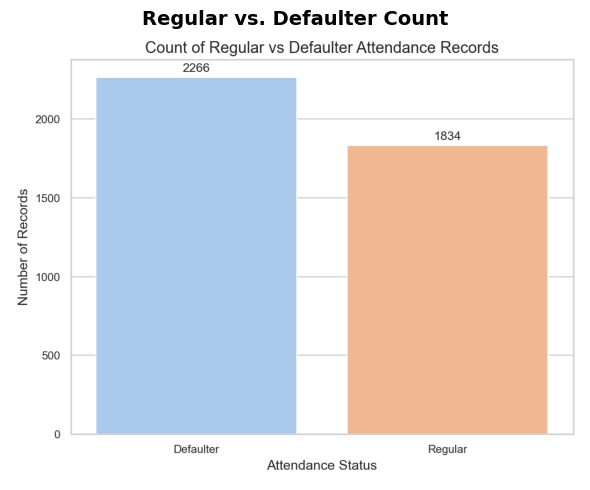


Attendance Status Counts:
  Defaulter    : 2,266 records (55.27%)
  Regular      : 1,834 records (44.73%)


In [4]:
img_path = os.path.join(CHARTS_DIR, "regular_defaulter_count.png")
if os.path.isfile(img_path):
    img = mpimg.imread(img_path)
    plt.figure(figsize=(8, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Regular vs. Defaulter Count", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("[RESULT NOT AVAILABLE - RUN THE RELEVANT NOTEBOOK]")

# Print counts from data
status_counts = df["Attendance_Status"].value_counts()
print("\nAttendance Status Counts:")
for label, count in status_counts.items():
    print(f"  {label:12} : {count:,} records ({count/len(df)*100:.2f}%)")

**Key Finding:**
- **Regular** (Attendance >= 75%): **1,834 records (44.73%)**
- **Defaulter** (Attendance < 75%): **2,266 records (55.27%)**
- Defaulters form a **slight majority** in the dataset, indicating that the 75% threshold is meaningful and challenging for many students.

### 5.3 Subject-wise Attendance

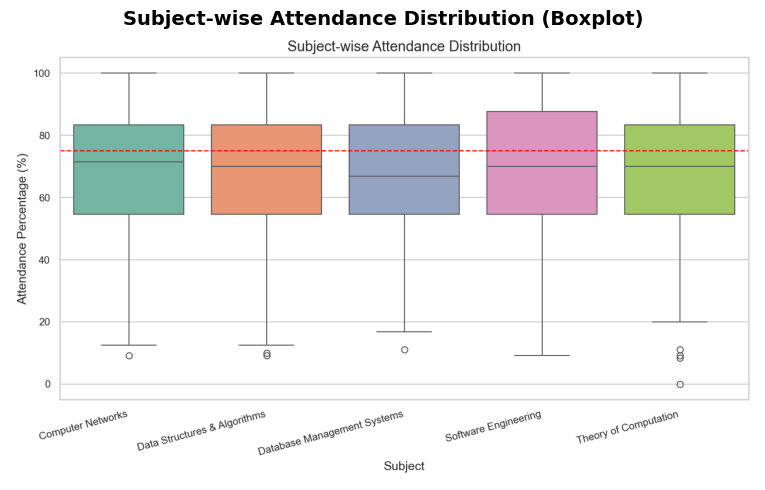

In [5]:
img_path = os.path.join(CHARTS_DIR, "subject_wise_attendance.png")
if os.path.isfile(img_path):
    img = mpimg.imread(img_path)
    plt.figure(figsize=(10, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Subject-wise Attendance Distribution (Boxplot)", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("[RESULT NOT AVAILABLE - RUN THE RELEVANT NOTEBOOK]")

**Subject-wise Mean Attendance (from EDA summary):**

| Subject | Mean Attendance (%) | Median Attendance (%) |
|---------|--------------------|-----------------------|
| Software Engineering | 69.12% | 70.00% |
| Computer Networks | 68.86% | 71.37% |
| Data Structures & Algorithms | 68.54% | 70.00% |
| Theory of Computation | 68.43% | 70.00% |
| Database Management Systems | 68.38% | 66.67% |

**Key Finding:** Subject-level variation is minimal (< 1%). Attendance behavior is primarily student-driven, not subject-driven.

### 5.4 Key Feature Correlations with Attendance

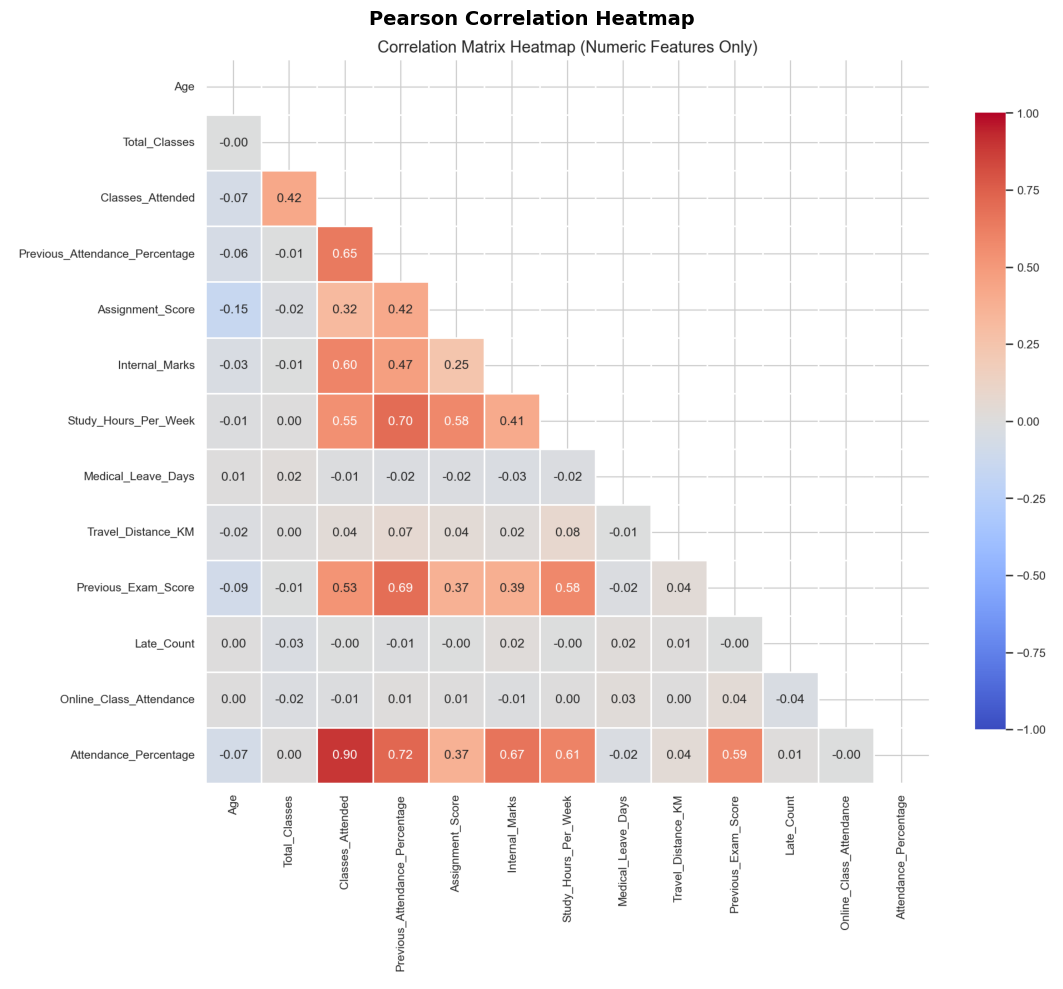

In [6]:
img_path = os.path.join(CHARTS_DIR, "correlation_heatmap.png")
if os.path.isfile(img_path):
    img = mpimg.imread(img_path)
    plt.figure(figsize=(12, 10))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Pearson Correlation Heatmap", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("[RESULT NOT AVAILABLE - RUN THE RELEVANT NOTEBOOK]")

**Top Feature Correlations with Attendance_Percentage (Pearson):**

| Feature | Correlation | Strength |
|---------|-------------|----------|
| `Classes_Attended` | 0.90 | Very Strong Positive (mathematical relationship) |
| `Previous_Attendance_Percentage` | 0.72 | Strong Positive |
| `Internal_Marks` | 0.67 | Strong Positive |
| `Study_Hours_Per_Week` | 0.61 | Moderate-Strong Positive |
| `Previous_Exam_Score` | 0.59 | Moderate-Strong Positive |
| `Assignment_Score` | 0.37 | Moderate Positive |
| `Travel_Distance_KM` | 0.04 | No Correlation |
| `Late_Count` | 0.01 | No Correlation |
| `Medical_Leave_Days` | -0.02 | No Correlation |
| `Age` | -0.07 | Negligible Negative |

**Key Insight:** Prior academic behavior (`Previous_Attendance_Percentage`, `Internal_Marks`, `Previous_Exam_Score`) is the strongest predictor of current attendance.

---

### 5.5 Additional Visualizations

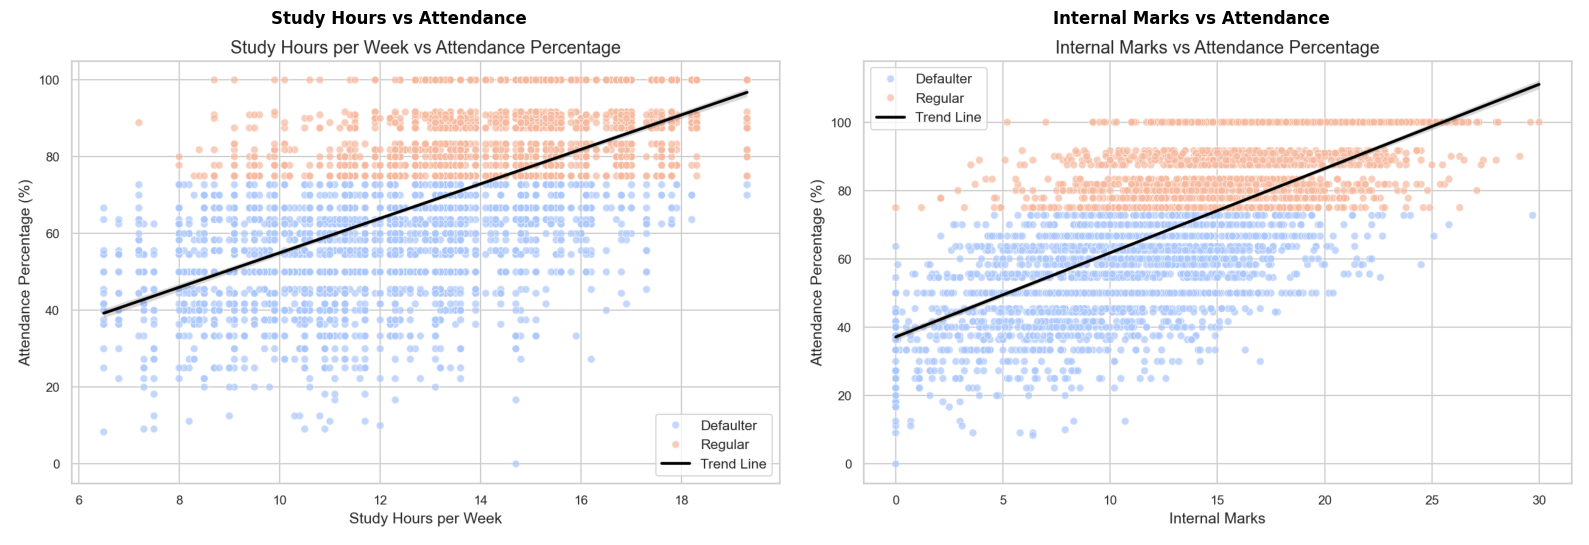

In [7]:
# Show study hours vs attendance and internal marks vs attendance side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, fname, title in [
    (axes[0], "study_hours_vs_attendance.png", "Study Hours vs Attendance"),
    (axes[1], "internal_marks_vs_attendance.png", "Internal Marks vs Attendance"),
]:
    img_path = os.path.join(CHARTS_DIR, fname)
    if os.path.isfile(img_path):
        img = mpimg.imread(img_path)
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(title, fontsize=12, fontweight="bold")
    else:
        ax.text(0.5, 0.5, "[RESULT NOT AVAILABLE\nRUN NOTEBOOK 01]",
                ha="center", va="center", transform=ax.transAxes)

plt.tight_layout()
plt.show()

## 6. Regression Model Comparison

**Goal:** Predict `Attendance_Percentage` (continuous value)
**Training Script:** `src/train_regression.py`
**Notebook:** `notebooks/02_regression_model.ipynb`
**Train/Test Split:** 80% / 20% | Random State: 42
**Features Used:** Gender, Department, Year, Semester, Subject, Age, Previous_Attendance_Percentage,
Assignment_Score, Internal_Marks, Study_Hours_Per_Week, Medical_Leave_Days,
Travel_Distance_KM, Previous_Exam_Score, Late_Count, Online_Class_Attendance

> **Note:** `Classes_Attended` and `Total_Classes` were **excluded** from features to avoid data leakage
> (these are mathematically derived from `Attendance_Percentage`).

In [8]:
# Load regression results from actual output file
if os.path.isfile(REG_RESULTS):
    reg_df = pd.read_csv(REG_RESULTS)
    print("=" * 80)
    print("  REGRESSION MODEL COMPARISON — Actual Results from regression_model_results.csv")
    print("=" * 80)
    display_df = reg_df.copy()
    for col in ["MAE", "MSE", "RMSE", "R2"]:
        display_df[col] = display_df[col].round(4)
    print(display_df.to_string(index=False))
    print()
    best_reg_row = reg_df.loc[reg_df["RMSE"].idxmin()]
    print(f"  Best Model (lowest RMSE): {best_reg_row['Model']}")
    print(f"    MAE  : {best_reg_row['MAE']:.4f}")
    print(f"    MSE  : {best_reg_row['MSE']:.4f}")
    print(f"    RMSE : {best_reg_row['RMSE']:.4f}")
    print(f"    R²   : {best_reg_row['R2']:.4f}")
else:
    print("[RESULT NOT AVAILABLE - RUN THE RELEVANT NOTEBOOK]")

  REGRESSION MODEL COMPARISON — Actual Results from regression_model_results.csv
                    Model     MAE      MSE    RMSE     R2
         LinearRegression  9.3679 134.8109 11.6108 0.6755
    DecisionTreeRegressor 10.2138 164.6423 12.8313 0.6037
    RandomForestRegressor  9.1673 130.7760 11.4357 0.6852
GradientBoostingRegressor  9.1786 129.8510 11.3952 0.6874

  Best Model (lowest RMSE): GradientBoostingRegressor
    MAE  : 9.1786
    MSE  : 129.8510
    RMSE : 11.3952
    R²   : 0.6874


### Regression Results Table (Actual Values)

| Model | MAE | MSE | RMSE | R² |
|-------|-----|-----|------|----|
| LinearRegression | 9.3679 | 134.8109 | 11.6108 | 0.6755 |
| DecisionTreeRegressor | 10.2138 | 164.6423 | 12.8313 | 0.6037 |
| RandomForestRegressor | 9.1673 | 130.7760 | 11.4357 | 0.6852 |
| **GradientBoostingRegressor** | **9.1786** | **129.8510** | **11.3952** | **0.6874** |

*Source: `outputs/regression_model_results.csv`*

## 7. Best Regression Model

**Best Model: `GradientBoostingRegressor`**

| Metric | Value |
|--------|-------|
| MAE | 9.1786 |
| MSE | 129.8510 |
| RMSE | **11.3952** (lowest among all regressors) |
| R² | **0.6874** (highest among all regressors) |

**Why GradientBoostingRegressor was selected:**
- It achieved the **lowest RMSE (11.3952)** and **highest R² (0.6874)** on the test set.
- Gradient Boosting builds an ensemble of weak learners (decision trees) sequentially, correcting errors from previous trees — ideal for this type of mixed categorical + numeric data.
- Compared to RandomForestRegressor (RMSE: 11.4357, R²: 0.6852), GradientBoosting shows marginal but consistent improvement.
- LinearRegression performed poorly (R²: 0.6755), confirming that non-linear relationships exist in the data.

**Interpretation of R² = 0.6874:**
The model explains approximately **68.7%** of the variance in student attendance percentage. This is a reasonable result for synthetic data where several features (e.g., `Travel_Distance_KM`, `Late_Count`) have near-zero correlation with the target.

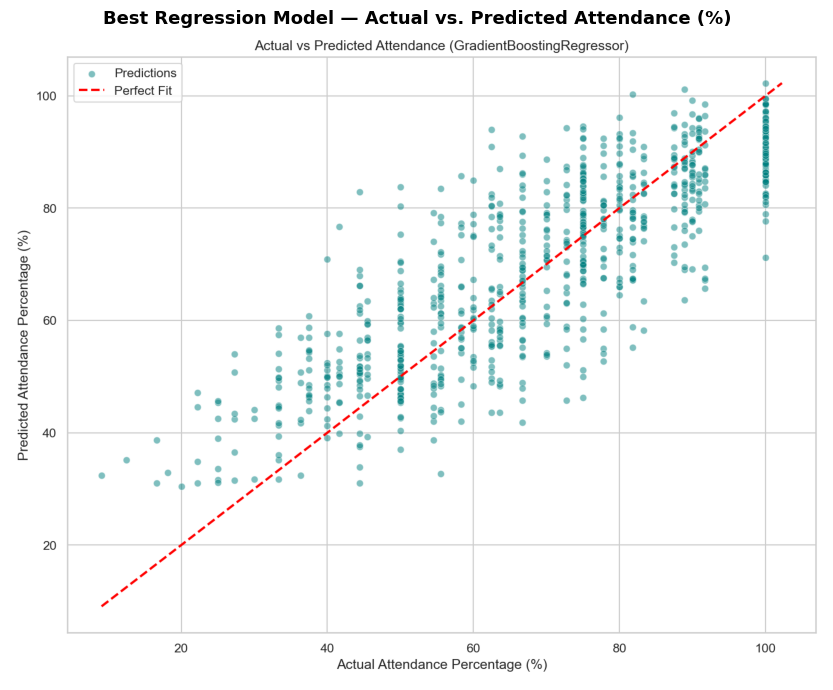

In [9]:
img_path = os.path.join(CHARTS_DIR, "regression_actual_vs_predicted.png")
if os.path.isfile(img_path):
    img = mpimg.imread(img_path)
    plt.figure(figsize=(9, 7))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Best Regression Model — Actual vs. Predicted Attendance (%)", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("[RESULT NOT AVAILABLE - RUN THE RELEVANT NOTEBOOK]")

## 8. Classification Model Comparison

**Goal:** Predict `Attendance_Status` — **Regular** (Attendance >= 75%) or **Defaulter** (Attendance < 75%)
**Training Script:** `src/train_classification.py`
**Notebook:** `notebooks/03_classification_model.ipynb`
**Train/Test Split:** 80% / 20% | Random State: 42 | Stratified split
**Target Encoding:** Regular → 0 | Defaulter → 1
**Features Used:** Same 15 predictors as regression (no leakage features)

In [10]:
# Load classification results from actual output file
if os.path.isfile(CLF_RESULTS):
    clf_df = pd.read_csv(CLF_RESULTS)
    print("=" * 100)
    print("  CLASSIFICATION MODEL COMPARISON — Actual Results from classification_model_results.csv")
    print("=" * 100)
    display_df = clf_df.copy()
    for col in ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]:
        display_df[col] = display_df[col].round(4)
    print(display_df.to_string(index=False))
    print()
    best_clf_row = clf_df.sort_values(by=["F1-score", "Recall"], ascending=False).iloc[0]
    print(f"  Best Model (highest F1-score + Recall): {best_clf_row['Model']}")
    print(f"    Accuracy  : {best_clf_row['Accuracy']:.4f}")
    print(f"    Precision : {best_clf_row['Precision']:.4f}")
    print(f"    Recall    : {best_clf_row['Recall']:.4f}")
    print(f"    F1-score  : {best_clf_row['F1-score']:.4f}")
    print(f"    ROC-AUC   : {best_clf_row['ROC-AUC']:.4f}")
else:
    print("[RESULT NOT AVAILABLE - RUN THE RELEVANT NOTEBOOK]")

  CLASSIFICATION MODEL COMPARISON — Actual Results from classification_model_results.csv
                     Model  Accuracy  Precision  Recall  F1-score  ROC-AUC
        LogisticRegression    0.8390     0.8512  0.8587    0.8549   0.9246
    DecisionTreeClassifier    0.8268     0.8659  0.8124    0.8383   0.8841
    RandomForestClassifier    0.8451     0.8655  0.8521    0.8587   0.9276
GradientBoostingClassifier    0.8463     0.8625  0.8587    0.8606   0.9189

  Best Model (highest F1-score + Recall): GradientBoostingClassifier
    Accuracy  : 0.8463
    Precision : 0.8625
    Recall    : 0.8587
    F1-score  : 0.8606
    ROC-AUC   : 0.9189


### Classification Results Table (Actual Values)

| Model | Accuracy | Precision | Recall | F1-Score | ROC-AUC |
|-------|----------|-----------|--------|----------|---------|
| LogisticRegression | 0.8390 | 0.8512 | 0.8587 | 0.8549 | 0.9246 |
| DecisionTreeClassifier | 0.8268 | 0.8659 | 0.8124 | 0.8383 | 0.8841 |
| RandomForestClassifier | 0.8451 | 0.8655 | 0.8521 | 0.8587 | 0.9276 |
| **GradientBoostingClassifier** | **0.8463** | **0.8625** | **0.8587** | **0.8606** | 0.9189 |

*Source: `outputs/classification_model_results.csv`*

> **Note:** The best model was selected based on **highest F1-score first, then Recall** — because in an early-warning attendance system, correctly identifying Defaulters (recall) is more important than avoiding false alarms.

## 9. Best Classification Model

**Best Model: `GradientBoostingClassifier`**

| Metric | Value |
|--------|-------|
| Accuracy | 0.8463 (84.63%) |
| Precision | 0.8625 (86.25%) |
| Recall | 0.8587 (85.87%) |
| **F1-Score** | **0.8606** (highest) |
| ROC-AUC | 0.9189 |

**Why GradientBoostingClassifier was selected:**
- It achieved the **highest F1-score (0.8606)** when ranking by F1-score then Recall.
- The model correctly identifies **85.87% of Defaulters** (Recall), crucial for early-warning systems.
- RandomForestClassifier had a higher ROC-AUC (0.9276) but slightly lower F1-score.
- LogisticRegression showed competitive performance (F1: 0.8549) with a much simpler model.
- The Gradient Boosting ensemble method handles the mixed feature types and non-linear decision boundary more effectively than a single tree.

**Interpretation:**
- **Precision (0.8625):** When the model predicts a student will be a Defaulter, it is correct 86.25% of the time.
- **Recall (0.8587):** The model correctly flags 85.87% of actual Defaulters — very important for early intervention.
- **ROC-AUC (0.9189):** The model has excellent discriminating power between Regular and Defaulter students.

## 10. Confusion Matrix Explanation

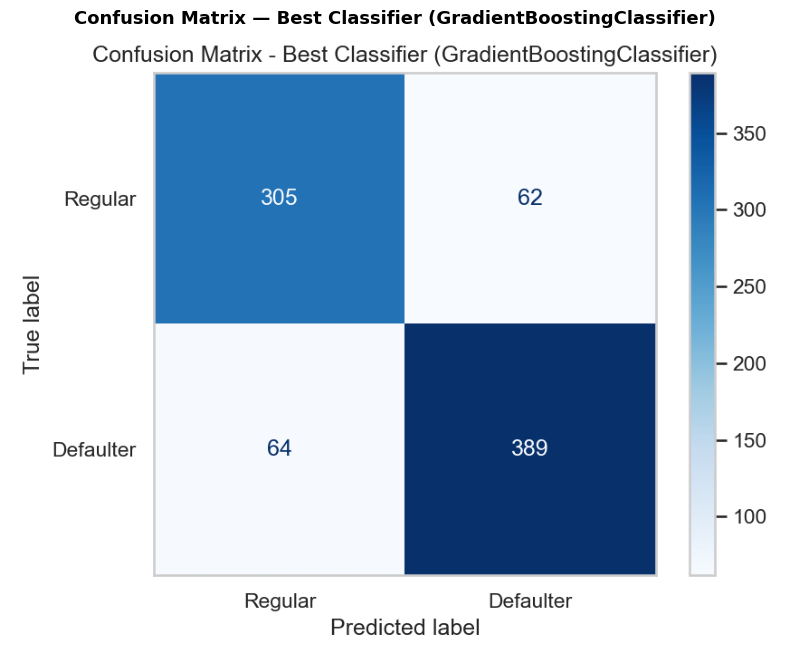

In [11]:
img_path = os.path.join(CHARTS_DIR, "best_classifier_confusion_matrix.png")
if os.path.isfile(img_path):
    img = mpimg.imread(img_path)
    plt.figure(figsize=(8, 7))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Confusion Matrix — Best Classifier (GradientBoostingClassifier)", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("[RESULT NOT AVAILABLE - RUN THE RELEVANT NOTEBOOK]")

### How to Read the Confusion Matrix

The confusion matrix is displayed with **Regular (0)** and **Defaulter (1)** as the two classes.

| | Predicted: Regular | Predicted: Defaulter |
|-|-------------------|---------------------|
| **Actual: Regular** | True Negatives (TN) — Correctly identified Regular students | False Positives (FP) — Regular students incorrectly flagged as Defaulters |
| **Actual: Defaulter** | False Negatives (FN) — Missed Defaulters (most costly error) | True Positives (TP) — Correctly identified Defaulters |

**In an early-warning attendance system:**
- **False Negatives (FN)** are the most costly — a Defaulter slips through without intervention.
- **False Positives (FP)** cause unnecessary alerts for Regular students — less harmful.
- This is why **Recall** was prioritized in model selection alongside F1-score.

---

## 11. Sample Prediction Using Saved Models

Demonstrate how the saved models can be loaded and used to make predictions on new student data.

In [12]:
# Load saved models
reg_model_loaded = False
clf_model_loaded = False

if os.path.isfile(BEST_REG_MODEL):
    best_regressor = joblib.load(BEST_REG_MODEL)
    reg_model_loaded = True
    print(f"✅ Regression model loaded: {BEST_REG_MODEL}")
else:
    print(f"[RESULT NOT AVAILABLE - best_regression_model.joblib not found]")

if os.path.isfile(BEST_CLF_MODEL):
    best_classifier = joblib.load(BEST_CLF_MODEL)
    clf_model_loaded = True
    print(f"✅ Classification model loaded: {BEST_CLF_MODEL}")
else:
    print(f"[RESULT NOT AVAILABLE - best_classification_model.joblib not found]")

✅ Regression model loaded: d:\Data_Science_attendence_project\models\best_regression_model.joblib
✅ Classification model loaded: d:\Data_Science_attendence_project\models\best_classification_model.joblib


In [13]:
# Create a sample student record for prediction
# Using the same feature columns as in training (no leakage features)

sample_student = pd.DataFrame([{
    "Gender": "Male",
    "Department": "Computer Engineering",
    "Year": "Third Year",
    "Semester": "Fifth Semester",
    "Subject": "Data Structures & Algorithms",
    "Age": 20,
    "Previous_Attendance_Percentage": 68.5,
    "Assignment_Score": 62.0,
    "Internal_Marks": 15.0,
    "Study_Hours_Per_Week": 10.0,
    "Medical_Leave_Days": 2,
    "Travel_Distance_KM": 8.5,
    "Previous_Exam_Score": 58.0,
    "Late_Count": 1,
    "Online_Class_Attendance": 70.0,
}])

print("Sample Student Record for Prediction:")
print(sample_student.T.to_string(header=False))
print()

if reg_model_loaded:
    predicted_attendance = best_regressor.predict(sample_student)[0]
    print(f"📈 Predicted Attendance Percentage : {predicted_attendance:.2f}%")
else:
    print("[RESULT NOT AVAILABLE - RUN THE RELEVANT NOTEBOOK]")

if clf_model_loaded:
    predicted_status_code = best_classifier.predict(sample_student)[0]
    predicted_status = "Defaulter" if predicted_status_code == 1 else "Regular"
    predicted_proba = best_classifier.predict_proba(sample_student)[0]
    print(f"🏷️  Predicted Attendance Status  : {predicted_status}")
    print(f"   Probability (Regular)  : {predicted_proba[0]:.4f}")
    print(f"   Probability (Defaulter): {predicted_proba[1]:.4f}")
else:
    print("[RESULT NOT AVAILABLE - RUN THE RELEVANT NOTEBOOK]")

Sample Student Record for Prediction:
Gender                                                  Male
Department                              Computer Engineering
Year                                              Third Year
Semester                                      Fifth Semester
Subject                         Data Structures & Algorithms
Age                                                       20
Previous_Attendance_Percentage                          68.5
Assignment_Score                                        62.0
Internal_Marks                                          15.0
Study_Hours_Per_Week                                    10.0
Medical_Leave_Days                                         2
Travel_Distance_KM                                       8.5
Previous_Exam_Score                                     58.0
Late_Count                                                 1
Online_Class_Attendance                                 70.0

📈 Predicted Attendance Percentage : 69.39%
🏷️ 

## 12. Practical Use Case

### How This System Can Help a Real Educational Institution

If deployed with real (properly anonymized) student data, this system could serve as an **automated early-warning attendance tool**:

| Stakeholder | Benefit |
|-------------|---------|
| **HOD / Academic Admin** | Get a department-wide view of students at risk of attendance shortage before the semester ends |
| **Class Teacher** | Receive automated alerts when a student crosses the Defaulter threshold or is predicted to do so |
| **Student Welfare Cell** | Proactively reach out to students predicted as Defaulters to understand and address root causes |
| **Students Themselves** | Receive early personal alerts about their own attendance trajectory |

### Workflow in a Real System

```
Raw Attendance Data → Data Preprocessing → Feature Engineering
                                                    ↓
                                        Load Trained Models
                                                    ↓
                        ┌──────────────────────────────────────────┐
                        │  Regression Model                         │
                        │  → Predict current attendance % trend     │
                        └──────────────────────────────────────────┘
                        ┌──────────────────────────────────────────┐
                        │  Classification Model                     │
                        │  → Flag as Regular or Defaulter           │
                        └──────────────────────────────────────────┘
                                                    ↓
                        Automated Alerts / Counseling Referrals
```

---

## 13. Ethical Considerations

| Principle | Implementation in This Project |
|-----------|-------------------------------|
| **Data Minimization** | Only statistical classroom parameters (not personal identity) used to generate the synthetic dataset. |
| **Anonymization** | All students have synthetic IDs (STU0001–STU0205). No real names, roll numbers, or emails exist anywhere in the project. |
| **No Re-identification Risk** | No mapping table between synthetic IDs and real students was ever created. |
| **Synthetic Data Labeling** | Every output file, notebook, and report clearly labels the data as SYNTHETIC. |
| **Honest Framing** | All conclusions are carefully worded to avoid over-generalizing synthetic findings to real-world behavior. |
| **Source Isolation** | The `private_original_data/` folder is never read, imported, or inspected by any project script. |
| **No Discrimination** | The `Defaulter` label is used for academic analysis only — not for any real-world academic action or judgment. |
| **Reproducibility** | Fixed random seeds (seed=42) ensure the exact same synthetic dataset can be reproduced by anyone. |

> ⚠️ **Important for Real-World Deployment:** Before applying any ML attendance prediction model to real student data, the institution must:
> - Obtain informed consent or follow institutional data governance policy.
> - Ensure FERPA / local education data privacy laws are complied with.
> - Have human oversight before acting on any model-based flagging decision.

---

## 14. Limitations

| # | Limitation | Impact |
|---|------------|--------|
| 1 | **Synthetic Data** | Results may not perfectly reflect real-world attendance dynamics. The statistical relationships are programmed, not empirically observed. |
| 2 | **No Causal Analysis** | The project identifies statistical correlations, not causal relationships. High `Internal_Marks` does not *cause* high attendance — both may be driven by student motivation. |
| 3 | **No Temporal Component** | Attendance is recorded as a period-level count, not as a week-by-week time series. A time-series model could detect early trend changes more effectively. |
| 4 | **Balanced Class Assumption** | The 75% threshold is used as the industry-standard cut-off. Real institutions may use different thresholds. |
| 5 | **No External Factors Modeled** | Variables like health conditions, socioeconomic background, family issues, and mental health — all real drivers of poor attendance — are not captured. |
| 6 | **Model Generalizability** | A model trained on synthetic data cannot be directly deployed on real student data without retraining on real (properly anonymized) records. |
| 7 | **Feature Leakage Exclusion** | `Classes_Attended` and `Total_Classes` were excluded from features to prevent data leakage, which reduces the model's R² but makes it genuinely predictive. |

---

## 15. Future Scope

| Direction | Description |
|-----------|-------------|
| **Time-Series Modeling** | Replace period-level snapshots with week-by-week attendance time series. Use LSTM or Prophet to detect attendance deterioration early in the semester. |
| **Real Data Integration** | Retrain the model pipeline on real (properly anonymized, consent-based) student attendance records for actual institutional deployment. |
| **Explainability (XAI)** | Apply SHAP (SHapley Additive Explanations) to explain why specific students are predicted as Defaulters — enabling teacher-friendly, actionable insights. |
| **Multi-Class Classification** | Expand beyond binary (Regular/Defaulter) to a 3-class model: Regular / At-Risk / Critical-Defaulter for more granular early-warning alerts. |
| **Dashboard Integration** | Build a web dashboard (e.g., using Streamlit or Flask) where academic coordinators can upload attendance data and get real-time predictions. |
| **Differential Privacy** | Apply differential privacy techniques when generating synthetic datasets to provide formal mathematical privacy guarantees. |
| **Cross-Institutional Benchmarking** | Compare synthetic results across simulated datasets from different departments, batch sizes, and semester structures. |

---

## 16. Final Conclusion

This project successfully demonstrated the complete lifecycle of a **privacy-preserving data science project** applied to the domain of student attendance prediction.

### What Was Accomplished

| Phase | Description | Status |
|-------|-------------|--------|
| **Phase 0** | Project setup, folder structure, plan, documentation | ✅ Complete |
| **Phase 1** | Synthetic dataset generation (205 students, 4,100 records, 21 features) with full validation (25/25 checks passed) | ✅ Complete |
| **Phase 2** | Exploratory Data Analysis — 9 charts, correlation analysis, department and subject-wise breakdown | ✅ Complete |
| **Phase 3** | Regression modeling — 4 models trained; GradientBoostingRegressor selected (RMSE: 11.3952, R²: 0.6874) | ✅ Complete |
| **Phase 4** | Classification modeling — 4 models trained; GradientBoostingClassifier selected (F1: 0.8606, ROC-AUC: 0.9189) | ✅ Complete |
| **Phase 5** | Summary report notebook (this file) | ✅ Complete |

### Key Results Summary

| Task | Best Model | Key Metric |
|------|-----------|------------|
| **Regression** | GradientBoostingRegressor | RMSE = 11.3952, R² = 0.6874 |
| **Classification** | GradientBoostingClassifier | F1-Score = 0.8606, ROC-AUC = 0.9189 |

### Key Insights from EDA

1. **55.27%** of records fall below the 75% attendance threshold (Defaulter category).
2. **Prior academic behavior** is the strongest predictor: `Previous_Attendance_Percentage` (r = 0.72), `Internal_Marks` (r = 0.67).
3. **Subject-level variation is minimal** — attendance behavior is primarily student-specific, not subject-driven.
4. **Logistical factors** (`Travel_Distance_KM`, `Late_Count`, `Medical_Leave_Days`) show near-zero correlation with attendance — suggesting these variables do not systematically predict attendance in this synthetic model.

### Privacy Assurance

> ✅ This project used **zero real student data** at any stage.
> All records are computer-generated. The `private_original_data/` folder is isolated and never accessed.
> This project is safe for academic submission and public portfolio sharing.

---
*Generated: 2026-08-29*
*Project: Privacy-Preserving Synthetic Student Attendance Analysis and Prediction System*
*Department: Computer Engineering & MCA | Semester: Fifth & Third*